In [1]:
import scipy.cluster.hierarchy as sch # to build dendrogram and build the plotting
from sklearn.cluster import AgglomerativeClustering
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sn

In [3]:
Airlines = pd.read_csv("/content/EastWestAirlines.csv")
Airlines

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1
...,...,...,...,...,...,...,...,...,...,...,...,...
3994,4017,18476,0,1,1,1,8525,4,200,1,1403,1
3995,4018,64385,0,1,1,1,981,5,0,0,1395,1
3996,4019,73597,0,3,1,1,25447,8,0,0,1402,1
3997,4020,54899,0,1,1,1,500,1,500,1,1401,0


In [4]:
Airlines.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [5]:
Airlines.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [6]:
Airlines.isnull().sum()

,0
ID#,0
Balance,0
Qual_miles,0
cc1_miles,0
cc2_miles,0
cc3_miles,0
Bonus_miles,0
Bonus_trans,0
Flight_miles_12mo,0
Flight_trans_12,0


In [7]:
Airlines.duplicated().sum()

0

In [8]:
Airlines1 =Airlines.copy()

In [9]:
Airlines1.drop(["ID#"], axis=1, inplace=True)

**Hierarchical Clustering**

In [10]:
Airlines1

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,28143,0,1,1,1,174,1,0,0,7000,0
1,19244,0,1,1,1,215,2,0,0,6968,0
2,41354,0,1,1,1,4123,4,0,0,7034,0
3,14776,0,1,1,1,500,1,0,0,6952,0
4,97752,0,4,1,1,43300,26,2077,4,6935,1
...,...,...,...,...,...,...,...,...,...,...,...
3994,18476,0,1,1,1,8525,4,200,1,1403,1
3995,64385,0,1,1,1,981,5,0,0,1395,1
3996,73597,0,3,1,1,25447,8,0,0,1402,1
3997,54899,0,1,1,1,500,1,500,1,1401,0


In [11]:
def norm_func(i): # function name is norm_func, we can give any name here.
    x = (i-i.min())/(i.max()-i.min()) # (Xi-min)/range (Feature Scaling), Range=max-min
    return x

In [12]:
# (i-i.min())/(i.max()-i.min())
Airlines1['Balance'].min(),Airlines1['Balance'].max()

(0, 1704838)

In [13]:
(28143-0)/(1704838-0)

0.01650772683386926

In [14]:
df_norm = norm_func(Airlines1.iloc[:,:])
df_norm

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,0.016508,0.0,0.00,0.0,0.0,0.000660,0.011628,0.000000,0.000000,0.843742,0.0
1,0.011288,0.0,0.00,0.0,0.0,0.000815,0.023256,0.000000,0.000000,0.839884,0.0
2,0.024257,0.0,0.00,0.0,0.0,0.015636,0.046512,0.000000,0.000000,0.847842,0.0
3,0.008667,0.0,0.00,0.0,0.0,0.001896,0.011628,0.000000,0.000000,0.837955,0.0
4,0.057338,0.0,0.75,0.0,0.0,0.164211,0.302326,0.067398,0.075472,0.835905,1.0
...,...,...,...,...,...,...,...,...,...,...,...
3994,0.010837,0.0,0.00,0.0,0.0,0.032330,0.046512,0.006490,0.018868,0.168917,1.0
3995,0.037766,0.0,0.00,0.0,0.0,0.003720,0.058140,0.000000,0.000000,0.167953,1.0
3996,0.043169,0.0,0.50,0.0,0.0,0.096505,0.093023,0.000000,0.000000,0.168797,1.0
3997,0.032202,0.0,0.00,0.0,0.0,0.001896,0.011628,0.016225,0.018868,0.168676,0.0


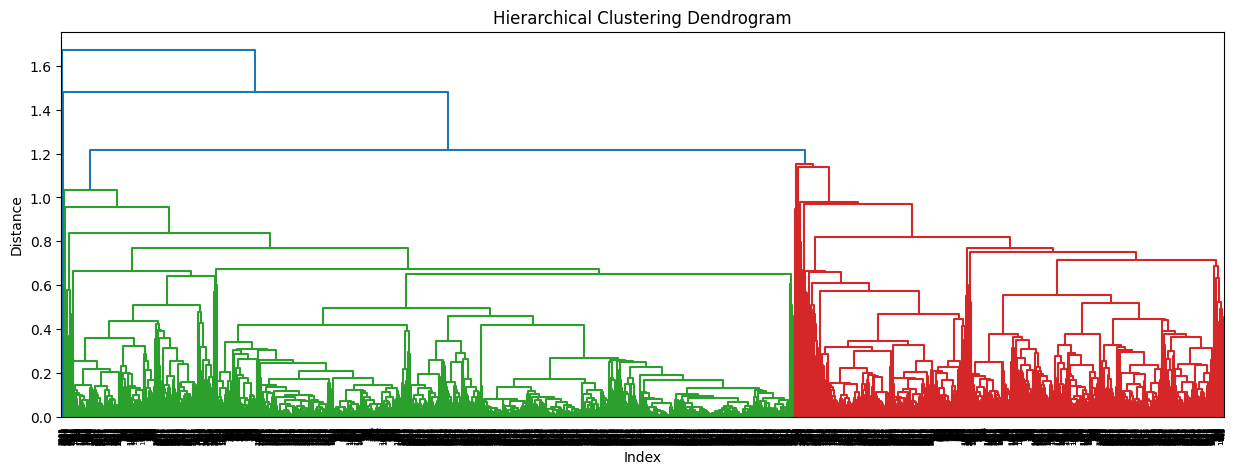

In [15]:
# create dendrogram
plt.figure(figsize=(15,5))
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Index")
plt.ylabel("Distance")
dendrogram = sch.dendrogram(sch.linkage(df_norm, method='average',metric="euclidean")) # average linkage
plt.show()

In [16]:
# create clusters, suppose got input from customer that go for 4 clusters
hc = AgglomerativeClustering(n_clusters=4, metric = 'euclidean',linkage = 'average')

In [17]:
hc

AgglomerativeClustering(linkage='average', n_clusters=4)

In [18]:
# save clusters for chart
y_hc = hc.fit_predict(df_norm) # apply fit_predict method on dataset df_norm. We will get cluster nos. in y_hc
Clusters=pd.DataFrame(y_hc,columns=['Cluster_No']) # append those no. of cluster numbers create dataframe

In [19]:
y_hc

array([1, 1, 1, ..., 0, 1, 1])

In [20]:
Clusters

,Cluster_No
0,1
1,1
2,1
3,1
4,0
...,...
3994,0
3995,0
3996,0
3997,1


In [21]:
# Now let us map this cluster membership to the data points
Airlines1['h_clusterid'] = Clusters

In [22]:
Airlines1

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,h_clusterid
0,28143,0,1,1,1,174,1,0,0,7000,0,1
1,19244,0,1,1,1,215,2,0,0,6968,0,1
2,41354,0,1,1,1,4123,4,0,0,7034,0,1
3,14776,0,1,1,1,500,1,0,0,6952,0,1
4,97752,0,4,1,1,43300,26,2077,4,6935,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
3994,18476,0,1,1,1,8525,4,200,1,1403,1,0
3995,64385,0,1,1,1,981,5,0,0,1395,1,0
3996,73597,0,3,1,1,25447,8,0,0,1402,1,0
3997,54899,0,1,1,1,500,1,500,1,1401,0,1


In [23]:
Airlines1['h_clusterid'].unique()

array([1, 0, 2, 3])

**K-Means**

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# We don't know the no. of clusters. So let's use K-Means and elbow method to choose this number of optimal clusters.
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings("ignore")

In [25]:
Airlines

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1
...,...,...,...,...,...,...,...,...,...,...,...,...
3994,4017,18476,0,1,1,1,8525,4,200,1,1403,1
3995,4018,64385,0,1,1,1,981,5,0,0,1395,1
3996,4019,73597,0,3,1,1,25447,8,0,0,1402,1
3997,4020,54899,0,1,1,1,500,1,500,1,1401,0


In [26]:
Airlines2 =Airlines.copy()

In [27]:
# Normalization / Standardisation function
from sklearn.preprocessing import StandardScaler  # built in function for standardization
scaler = StandardScaler() # scaler is an object name of StandardScalar class, you can give any name
scaled_Air_df = scaler.fit_transform(Airlines2.iloc[:,1:]) # fit_transform() is a method of StandardScalar class
scaled_Air_df

array([[-4.51140783e-01, -1.86298687e-01, -7.69578406e-01, ...,
        -3.62167870e-01,  1.39545434e+00, -7.66919299e-01],
       [-5.39456874e-01, -1.86298687e-01, -7.69578406e-01, ...,
        -3.62167870e-01,  1.37995704e+00, -7.66919299e-01],
       [-3.20031232e-01, -1.86298687e-01, -7.69578406e-01, ...,
        -3.62167870e-01,  1.41192021e+00, -7.66919299e-01],
       ...,
       [-4.29480975e-05, -1.86298687e-01,  6.83121167e-01, ...,
        -3.62167870e-01, -1.31560393e+00,  1.30391816e+00],
       [-1.85606976e-01, -1.86298687e-01, -7.69578406e-01, ...,
        -9.85033311e-02, -1.31608822e+00, -7.66919299e-01],
       [-7.00507951e-01, -1.86298687e-01, -7.69578406e-01, ...,
        -3.62167870e-01, -1.31754109e+00, -7.66919299e-01]])

In [47]:
#The K-means algorithm aims to choose centroids that minimise the inertia, or within-cluster sum-of-squares criterion:

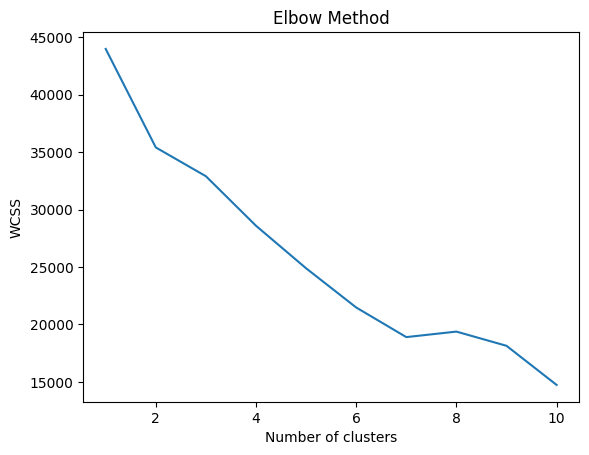

In [28]:
# Inertia measures how well a dataset was clustered by K-Means.
# It is calculated by measuring the distance between each data point and its centroid, squaring this distance,
# and summing these squares across one cluster.
# A good model is one with low inertia AND a low number of clusters (K).

# To plot the elbow method graph, we need to compute the WCSS (Within Cluster Sum of Squares)
# Let us say max. no. of clusters could be 10.
# As we are going to have 10 iterations we are going to write a for loop to create a list of 10 WCSS for the no. of clusters

wcss = [] # within cluster sum of square. Initialize WCSS and begin the loop
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i,init='k-means++',max_iter=300,random_state=0) #max_iter=300 is default value.
    kmeans.fit(scaled_Air_df) #  use fit method to fit the kmeans object to our scaled dataframe
    wcss.append(kmeans.inertia_)# another name for wcss is inertia.
    # In WCSS list we will append all distances i.e if cluster is 10 what is the value,
    # if 9 what is value and so on upto 1.

plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [29]:
wcss

[43989.0000000001,
 35409.516629861384,
 32901.45804218546,
 28589.20585898687,
 24884.115340435033,
 21470.51454980924,
 18891.750169018418,
 19371.700292851994,
 18134.257221538734,
 14727.658831288609]

In [30]:
kmeans = KMeans(n_clusters=4,random_state=0) # pass no. of clusters as 4
predict=kmeans.fit_predict(scaled_Air_df)# assign cluster numbers to universities

In [31]:
predict

array([1, 1, 1, ..., 0, 1, 1], dtype=int32)

In [32]:
clusters_new = KMeans(n_clusters=3, random_state=0)
new_predict=clusters_new.fit_predict(scaled_Air_df)

In [33]:
new_predict

array([1, 1, 1, ..., 0, 1, 1], dtype=int32)

In [34]:
#Assign clusters to the data set
Airlines2['clusterid_new'] = predict

In [84]:
Airlines2

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,clusterid_new
0,1,28143,0,1,1,1,174,1,0,0,7000,0,1
1,2,19244,0,1,1,1,215,2,0,0,6968,0,1
2,3,41354,0,1,1,1,4123,4,0,0,7034,0,1
3,4,14776,0,1,1,1,500,1,0,0,6952,0,1
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3994,4017,18476,0,1,1,1,8525,4,200,1,1403,1,0
3995,4018,64385,0,1,1,1,981,5,0,0,1395,1,0
3996,4019,73597,0,3,1,1,25447,8,0,0,1402,1,0
3997,4020,54899,0,1,1,1,500,1,500,1,1401,0,1


In [35]:
#Univ.groupby('clusterid_new').agg(['mean']).reset_index()
Airlines2.groupby('clusterid_new').mean().drop('ID#', axis=1)

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
clusterid_new,,,,,,,,,,,
0,58005.687723,233.840286,1.690107,1.019070,1.000000,10751.059595,10.750894,421.438617,1.292014,4252.010727,0.995232
1,43666.553664,71.563121,1.313002,1.016076,1.000473,4906.620804,7.259574,157.724823,0.472813,3636.870449,0.000000
2,138360.867696,129.369350,4.110254,1.002205,1.052922,48924.512679,19.890849,379.740904,1.162073,5028.368247,0.586549
3,201571.514493,807.449275,2.268116,1.043478,1.000000,34710.615942,28.847826,5856.253623,17.065217,4709.934783,0.826087


In [36]:
Airlines2[Airlines2['clusterid_new']==0].shape[0]

839

In [37]:
Airlines2[Airlines2['clusterid_new']==1].shape[0]

2115

In [38]:
Airlines2[Airlines2['clusterid_new']==2].shape[0]

907

In [39]:
Airlines2[Airlines2['clusterid_new']==3].shape[0]

138

**DB Scan**

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.figsize'] = (10,5)
plt.rcParams['figure.dpi'] = 250
sns.set_style('darkgrid') # background
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [41]:
Airlines3 =Airlines.copy()

In [42]:
Airlines3

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1
...,...,...,...,...,...,...,...,...,...,...,...,...
3994,4017,18476,0,1,1,1,8525,4,200,1,1403,1
3995,4018,64385,0,1,1,1,981,5,0,0,1395,1
3996,4019,73597,0,3,1,1,25447,8,0,0,1402,1
3997,4020,54899,0,1,1,1,500,1,500,1,1401,0


In [43]:
Airlines3.describe().iloc[:,1:]
# check outliers looking at max: almost in all columns outliers are present at upper extreme

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


<Axes: >

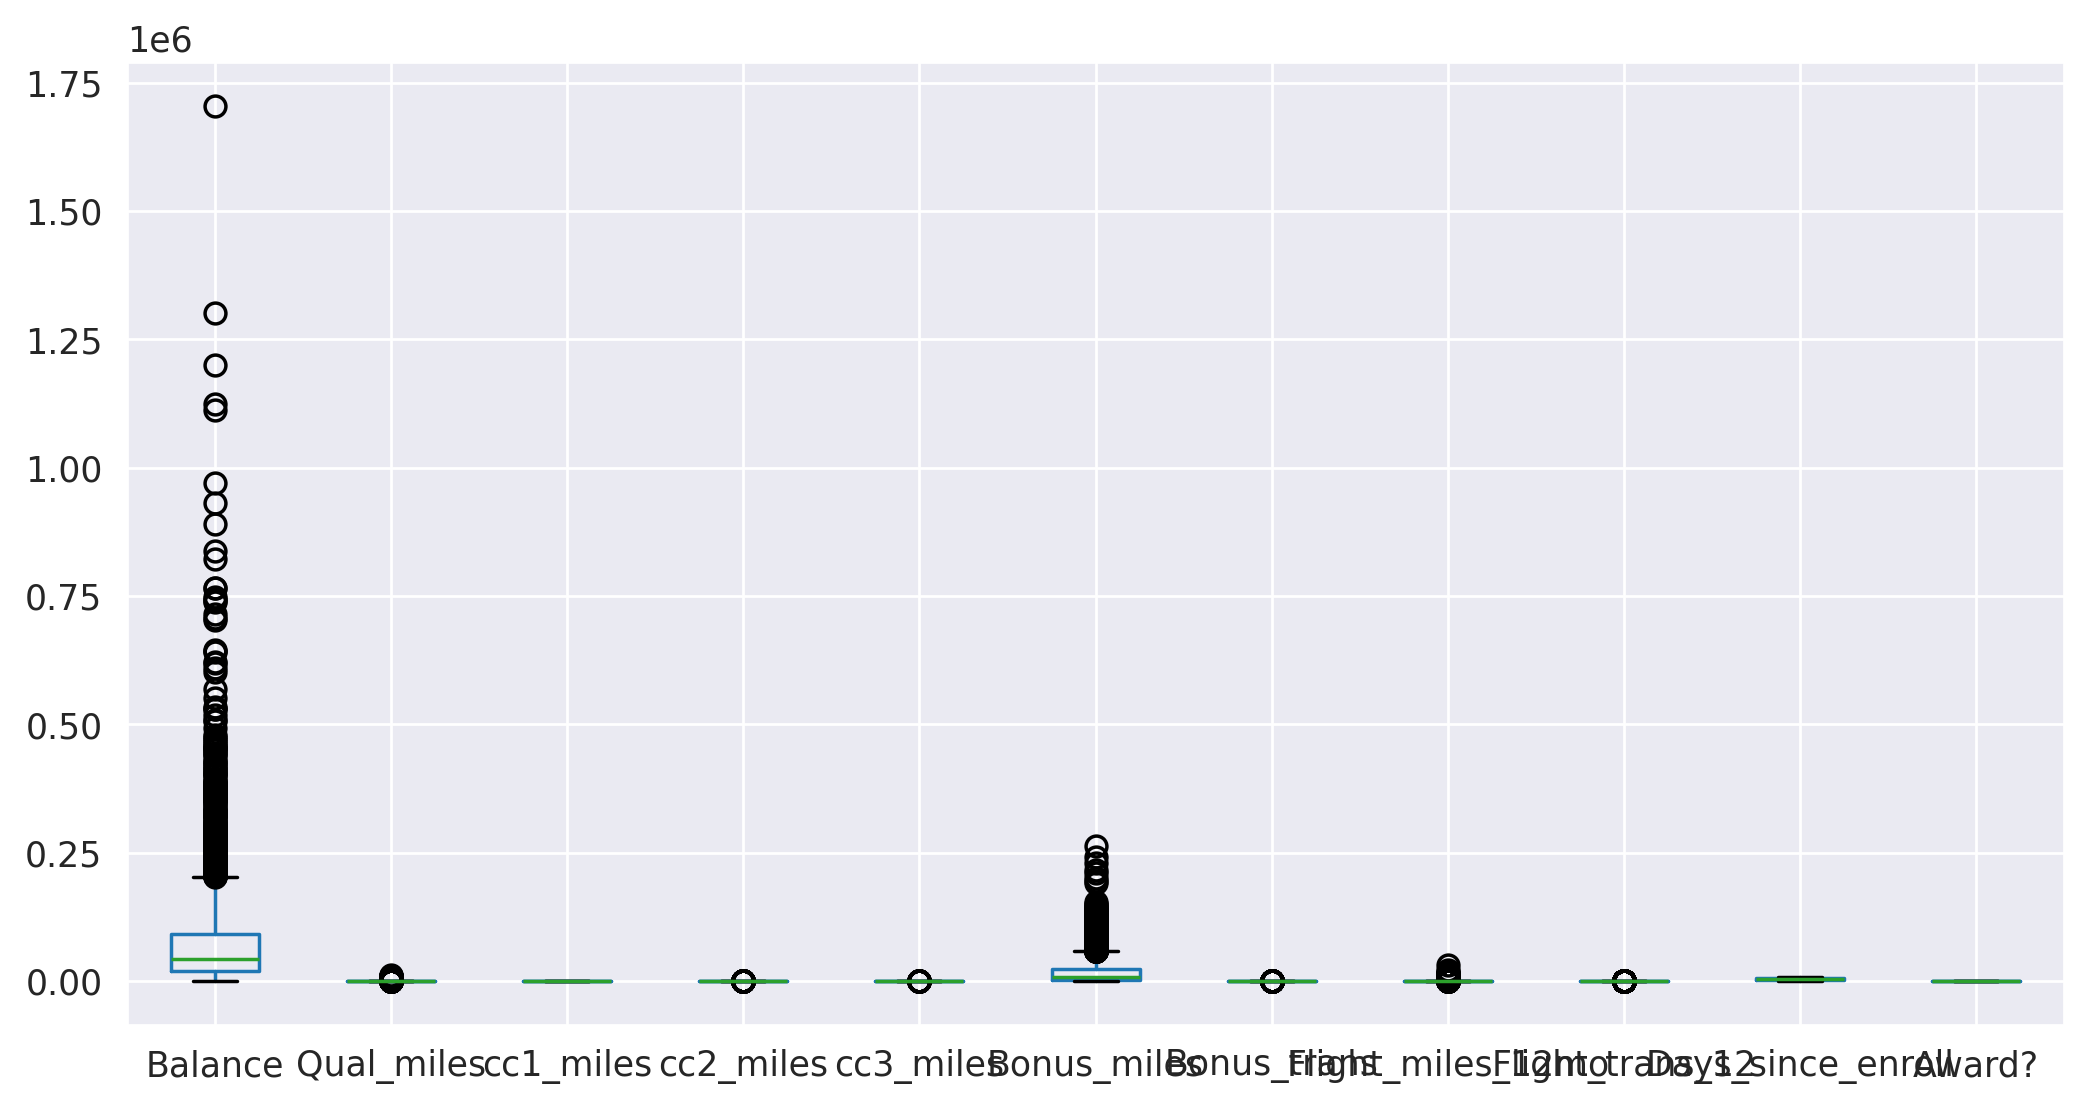

In [44]:
# compare outliers with boxplot
Airlines3.iloc[:,1:].boxplot()

In [45]:
# Feature scaling
from sklearn.preprocessing import StandardScaler

In [46]:
sc = StandardScaler()

In [47]:
x = sc.fit_transform(Airlines3.iloc[:,1:])
x

array([[-4.51140783e-01, -1.86298687e-01, -7.69578406e-01, ...,
        -3.62167870e-01,  1.39545434e+00, -7.66919299e-01],
       [-5.39456874e-01, -1.86298687e-01, -7.69578406e-01, ...,
        -3.62167870e-01,  1.37995704e+00, -7.66919299e-01],
       [-3.20031232e-01, -1.86298687e-01, -7.69578406e-01, ...,
        -3.62167870e-01,  1.41192021e+00, -7.66919299e-01],
       ...,
       [-4.29480975e-05, -1.86298687e-01,  6.83121167e-01, ...,
        -3.62167870e-01, -1.31560393e+00,  1.30391816e+00],
       [-1.85606976e-01, -1.86298687e-01, -7.69578406e-01, ...,
        -9.85033311e-02, -1.31608822e+00, -7.66919299e-01],
       [-7.00507951e-01, -1.86298687e-01, -7.69578406e-01, ...,
        -3.62167870e-01, -1.31754109e+00, -7.66919299e-01]])

In [ ]:
#Model Building

In [48]:
from sklearn.cluster import DBSCAN

In [50]:
db = DBSCAN(eps=0.8, min_samples=6)
y = db.fit_predict(x)
y
# unique nos: -1,0,1,2,3
# -1:outliers, 0 to 3: 4 clusters are there.

array([0, 0, 0, ..., 1, 0, 0])

In [51]:
# prompt: unique values in y
import pandas as pd
y_series = pd.Series(y)
# Get unique values
unique_values = y_series.unique()
# Print the unique values
unique_values

array([ 0, -1,  1,  2,  3])

In [52]:
x

array([[-4.51140783e-01, -1.86298687e-01, -7.69578406e-01, ...,
        -3.62167870e-01,  1.39545434e+00, -7.66919299e-01],
       [-5.39456874e-01, -1.86298687e-01, -7.69578406e-01, ...,
        -3.62167870e-01,  1.37995704e+00, -7.66919299e-01],
       [-3.20031232e-01, -1.86298687e-01, -7.69578406e-01, ...,
        -3.62167870e-01,  1.41192021e+00, -7.66919299e-01],
       ...,
       [-4.29480975e-05, -1.86298687e-01,  6.83121167e-01, ...,
        -3.62167870e-01, -1.31560393e+00,  1.30391816e+00],
       [-1.85606976e-01, -1.86298687e-01, -7.69578406e-01, ...,
        -9.85033311e-02, -1.31608822e+00, -7.66919299e-01],
       [-7.00507951e-01, -1.86298687e-01, -7.69578406e-01, ...,
        -3.62167870e-01, -1.31754109e+00, -7.66919299e-01]])

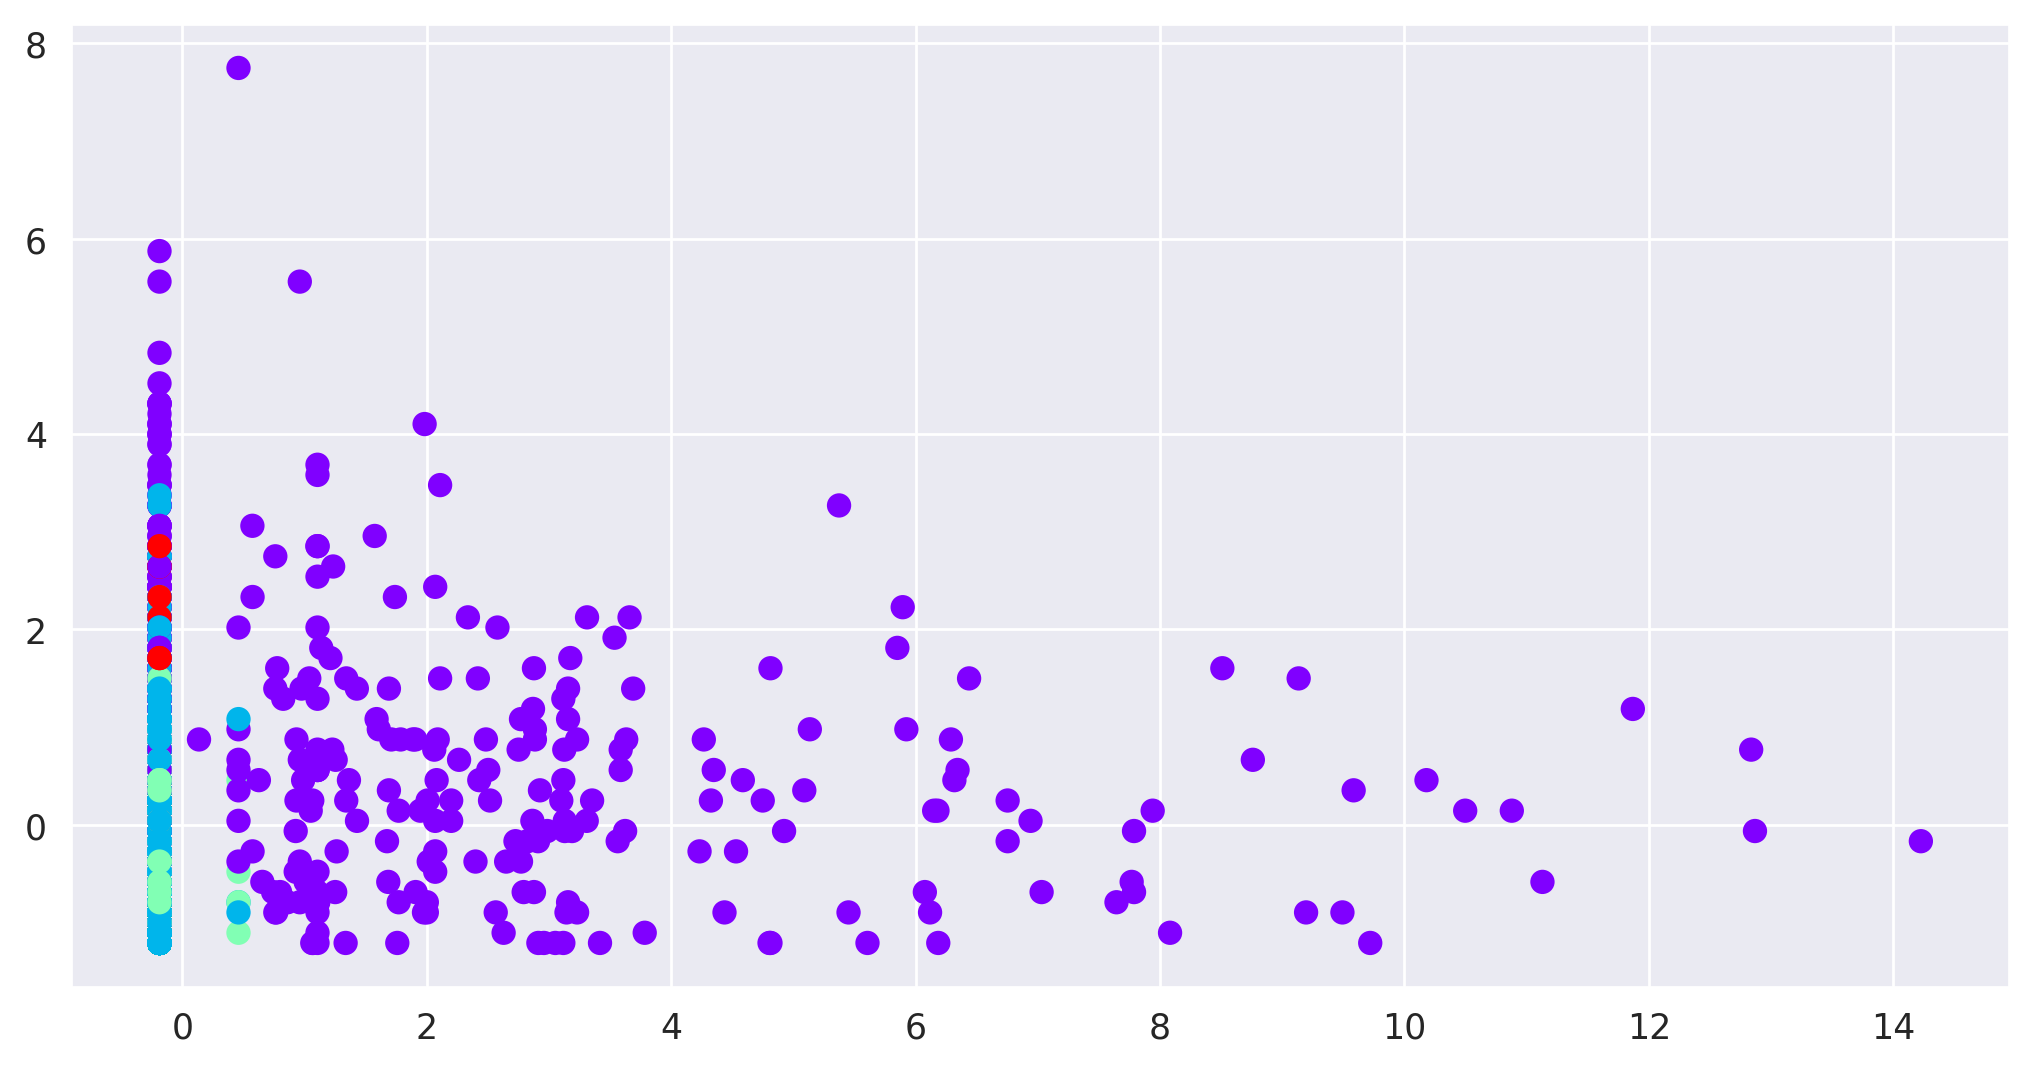

In [53]:
plt.scatter(x[:,1],x[:,6],c=y,cmap='rainbow')
# c=y i.e. give color coding to each data point depending upon which cluster it belong to
# In y we have cluster no for each data point and outlier information if it is -1
# plot of any 2 columns from x i.e. index 1 and 6 column
# clusters are overlapping, purple data points are far away so they are outliers. So not a good model
# Confirm it with silhouette score

In [54]:
from sklearn.metrics import silhouette_score

In [55]:
silhouette_score(x,y) # parameters: x:standardized version of data, y:cluster lables
# score is approximately near to zero i.e. clusters are overlapping

0.16002351310807247

In [ ]:
#Hyperparameter Tuning

**Selecting Min_samples or MinPts:**

Number of columns + 1: 11+1=12

Number of columns * 2: 11*2=22

Always keep min_samples at least 3



**Find best eps value (K-dist Plot)**

1)This technique calculates the average distance between each point and
its k nearest neighbours where k is the MinPts value you selected.

2)Similar to elbow graph: On x-axis: distance, y-axis:eps, let's say min_samp: 3. It will draw circles of eps size around each data point. Then avg distance of all data points which belong to same cluster will be calculated. If eps is high, avg distance will also be very high.

3)Then another eps value will be taken and process is repeated, avg. distance will be calculated. This will be done for more than 100 times. Opposite to elbow graph, graph will be plotted -/ (At joint level is the elbow, check drastic decrease.)

4)The average k-distances are then plotted in ascending order on a k-distance graph. You will find the optimal value foe eps at the point of maximum curvature (i.e. where the graph has the greatest slope)

In [56]:
from sklearn.neighbors import NearestNeighbors
# NearestNeighbors will calculate avg distance by considering nearest data point

In [57]:
neighbor = NearestNeighbors(n_neighbors=3).fit(x) # fit will calculate distance using euclidean distance method
# n_neighbors:min sample. Calculate nearest 3 data points of each data point
# eps values will be selected randomly by algorithm

In [58]:
# distances (calculated with eps value) are stored in neighbor
d,index = neighbor.kneighbors(x)
# kneighbors() will show distances.
# It returns 2 values, d:euclidean distances: 3 distances are there in every list as we have selected min sample as 3
# row index: which data point is close to which other data point

In [59]:
neighbor.kneighbors(x)
# in d: [0.        , 0.11184685, 0.12034246]
# 1st column value: 0 represents distance of 1st nearest neighbor
# 2nd col. value: 0.11184685 represents distance of 2nd nearest neighbor
# 3rd col value: 0.12034246 represents distance of 3rd nearest neighbor
# in 1st col everywhere distance is 0 because it's the distance between x and itself so ignore 1st column

# Index: [  0,   378, 363]
# row 0 and 378 are close to each other
# distance between row 0 and row 0 is 0,
# between row 0 and row 378 is 0.11184685 , between row 0 and row 363 is 0.12034246 and so on

# So row 0 and 378 are closest to each other
# row 1 and 3 are closest to each other
# row 2 and 338 are closest to each other and so on

(array([[0.        , 0.11184685, 0.12034246],
        [0.        , 0.11406276, 0.11437601],
        [0.        , 0.16540223, 0.19458949],
        ...,
        [0.        , 0.16614779, 0.28024323],
        [0.        , 0.25725534, 0.27167409],
        [0.        , 0.00270574, 0.0112955 ]]),
 array([[   0,  378,  363],
        [   1,    3,  363],
        [   2,  338,  368],
        ...,
        [3996, 3877, 3800],
        [3997, 3623, 3882],
        [3998, 3491, 3455]]))

In [60]:
d

array([[0.        , 0.11184685, 0.12034246],
       [0.        , 0.11406276, 0.11437601],
       [0.        , 0.16540223, 0.19458949],
       ...,
       [0.        , 0.16614779, 0.28024323],
       [0.        , 0.25725534, 0.27167409],
       [0.        , 0.00270574, 0.0112955 ]])

In [61]:
index

array([[   0,  378,  363],
       [   1,    3,  363],
       [   2,  338,  368],
       ...,
       [3996, 3877, 3800],
       [3997, 3623, 3882],
       [3998, 3491, 3455]])

In [62]:
d[:,1]

array([0.11184685, 0.11406276, 0.16540223, ..., 0.16614779, 0.25725534,
       0.00270574])

In [63]:
distance = np.sort(d[:,1]) # consider all rows and 1st nearest neighbor values i.e.2nd column

In [64]:
distance

array([0.00000000e+00, 0.00000000e+00, 2.26431613e-03, ...,
       6.61657940e+00, 6.67864158e+00, 7.46132314e+00])

Text(0.5, 1.0, 'K-Distance Graph')

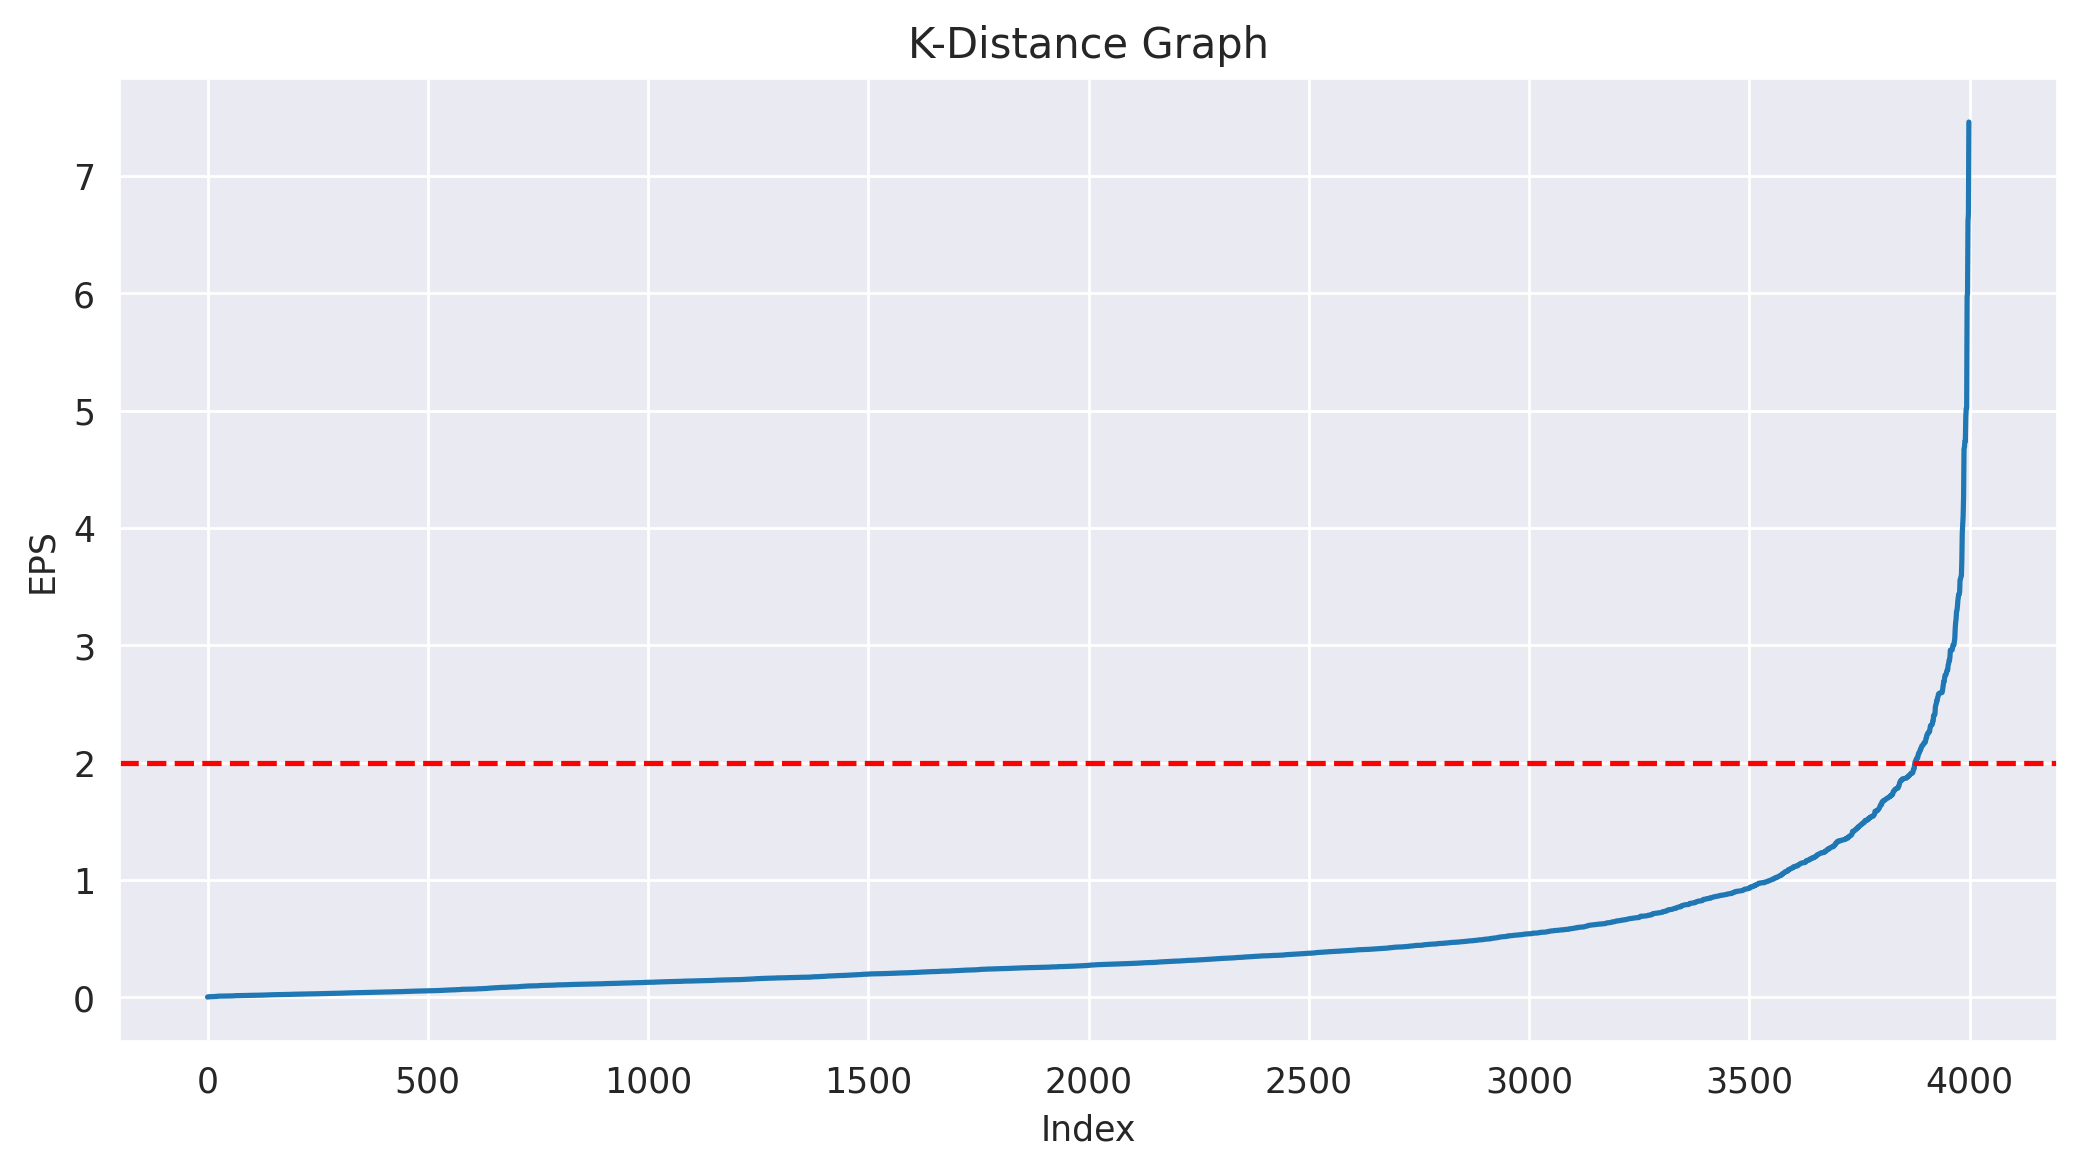

In [126]:
plt.plot(distance)
plt.axhline(y=2, linestyle = '--', color='red') # y=2 means draw horizontal lint at eps=2
plt.xlabel('Index')
plt.ylabel('EPS')
plt.title('K-Distance Graph')

**Model Evaluation**

In [66]:
from sklearn.cluster import DBSCAN

In [173]:
db = DBSCAN(eps=3, min_samples=3) # default eps=0.5
yp = db.fit_predict(x)
yp

array([0, 0, 0, ..., 0, 0, 0])

In [174]:
# prompt: unique values in y
import pandas as pd
y_series = pd.Series(yp)
# Get unique values
unique_values = y_series.unique()
# Print the unique values
unique_values

array([ 0, -1,  1,  2,  3,  5,  4])

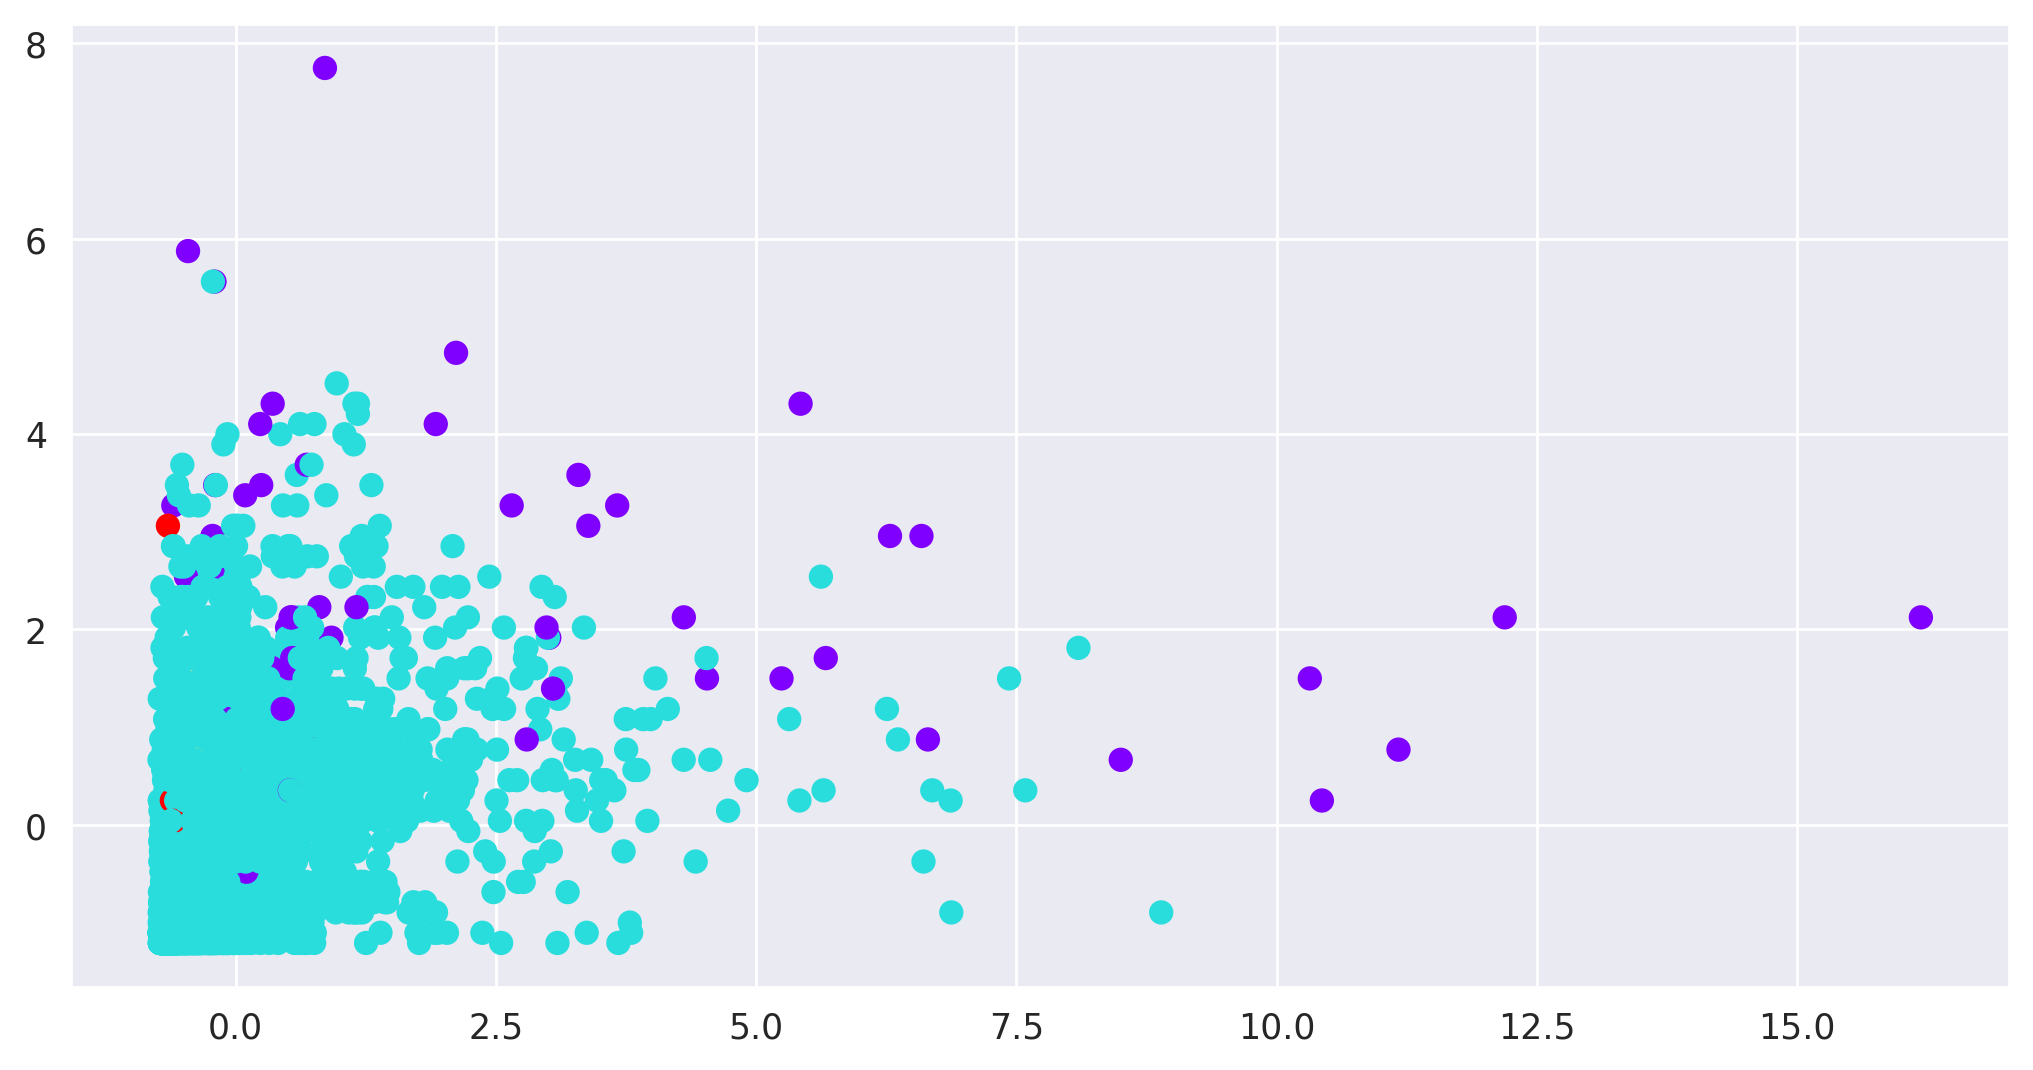

In [172]:
plt.scatter(x[:,0],x[:,6],c=yp,cmap='rainbow') # try cmap=rainbow
# purple data points are outliers

In [175]:
silhouette_score(x,yp)#good Score

0.5390274286985567

In [176]:
# Analyze the clusters
Airlines3['Cluster'] = yp
Airlines3

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,Cluster
0,1,28143,0,1,1,1,174,1,0,0,7000,0,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3994,4017,18476,0,1,1,1,8525,4,200,1,1403,1,0
3995,4018,64385,0,1,1,1,981,5,0,0,1395,1,0
3996,4019,73597,0,3,1,1,25447,8,0,0,1402,1,0
3997,4020,54899,0,1,1,1,500,1,500,1,1401,0,0


In [177]:
Airlines3[Airlines3['Cluster'] == -1]

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,Cluster
8,9,443003,0,3,2,1,1753,43,3850,12,6948,1,-1
106,109,96627,1182,1,1,3,49059,26,2300,9,6738,1,-1
126,129,602064,0,5,1,1,194753,26,2250,10,7652,1,-1
151,154,930410,0,5,1,1,211284,18,2250,6,7640,1,-1
186,190,707079,0,4,1,1,57173,40,3450,12,7523,1,-1
190,194,123516,0,5,1,1,240544,31,500,2,7507,1,-1
220,224,1302051,2706,5,1,1,90653,32,3050,7,7467,1,-1
275,279,1704838,0,1,1,1,17108,32,4823,23,7283,1,-1
343,348,112501,0,1,1,2,19140,11,0,0,7101,0,-1
380,385,377252,0,5,1,1,230629,30,6393,13,6996,1,-1


In [178]:
Airlines3[Airlines3['Cluster'] == -1].shape[0]

51

In [179]:
Airlines3['Cluster'].value_counts()

,count
Cluster,
0,3898
-1,51
2,25
1,14
3,5
5,3
4,3


In [180]:
# extract only normal data points
data = Airlines3[Airlines3['Cluster']!= -1]
data

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,Cluster
0,1,28143,0,1,1,1,174,1,0,0,7000,0,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3994,4017,18476,0,1,1,1,8525,4,200,1,1403,1,0
3995,4018,64385,0,1,1,1,981,5,0,0,1395,1,0
3996,4019,73597,0,3,1,1,25447,8,0,0,1402,1,0
3997,4020,54899,0,1,1,1,500,1,500,1,1401,0,0


In [181]:
data.groupby('Cluster').agg('mean')

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
Cluster,,,,,,,,,,,,
0,2019.620575,70108.966650,125.34197,2.053361,1.0,1.0,16236.394561,11.256542,392.526680,1.199590,4105.397127,0.363520
1,2154.214286,45781.714286,0.00000,1.000000,3.0,1.0,20147.571429,16.928571,410.000000,1.714286,4137.642857,0.357143
2,2400.600000,39187.040000,0.00000,1.120000,2.0,1.0,11107.040000,14.840000,224.000000,0.800000,3703.240000,0.320000
3,1757.400000,102022.600000,0.00000,3.600000,1.0,4.0,90060.800000,27.000000,210.000000,0.600000,4730.200000,0.400000
4,1246.333333,56112.333333,0.00000,3.333333,1.0,5.0,105025.666667,28.000000,366.666667,1.000000,5223.666667,1.000000
5,1088.333333,62703.666667,9935.00000,1.666667,1.0,1.0,8572.333333,11.333333,1166.666667,6.000000,5699.000000,1.000000
